In [28]:
# imports
import os
import cv2
import matplotlib.pyplot as plt
import kagglehub
import tensorflow as tf
from tensorflow.keras import layers, models
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

In [29]:
# download data
path = kagglehub.dataset_download("rashikrahmanpritom/plant-disease-recognition-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plant-disease-recognition-dataset' dataset.
Path to dataset files: /kaggle/input/plant-disease-recognition-dataset


plant-disease-recognition-dataset/ (0 files)
    Validation/ (0 files)
        Validation/ (0 files)
            Healthy/ (20 files)
            Rust/ (20 files)
            Powdery/ (20 files)
    Test/ (0 files)
        Test/ (0 files)
            Healthy/ (50 files)
            Rust/ (50 files)
            Powdery/ (50 files)
    Train/ (0 files)
        Train/ (0 files)
            Healthy/ (458 files)
            Rust/ (434 files)
            Powdery/ (430 files)

Sample Image Shape: (2672, 4000, 3)
Pixel Range: 0 to 243


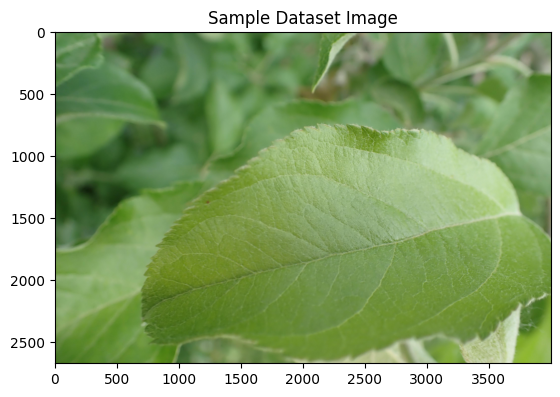

In [30]:
# function to look at the directory structure to find the image path
def explore_data(base_path):
    for root, dirs, files in os.walk(base_path):
        level = root.replace(base_path, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f"{indent}{os.path.basename(root)}/ ({len(files)} files)")

# function to find structural properties of the images
def check_sample_image(img_path):
    img = cv2.imread(img_path)
    if img is not None:
        print(f"\nSample Image Shape: {img.shape}")
        print(f"Pixel Range: {img.min()} to {img.max()}")

        # show a sample image
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Sample Dataset Image")
        plt.show()
    else:
        print("Could not read image.")

# apply the functions to the data
explore_data(path)

# find the first image file to inspect
sample_file = None
for root, dirs, files in os.walk(path):
    for f in files:
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            sample_file = os.path.join(root, f)
            break
    if sample_file: break

if sample_file:
    check_sample_image(sample_file)

In [31]:
# define paths
train_dir = os.path.join(path, "Train/Train")
val_dir = os.path.join(path, "Validation/Validation")

IMG_SIZE = (224, 224) # downscale images from 2672x4000 to improve efficiency
BATCH_SIZE = 32

# load training data
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# load validation data
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# define normalization layer
normalization_layer = tf.keras.layers.Rescaling(1./255)

# apply normalization to the datasets
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# define augmentation
# added this to help reduce the overfitting
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])

Found 1322 files belonging to 3 classes.
Found 60 files belonging to 3 classes.


In [ ]:

# define the model
model = models.Sequential([
    # input layer:
    layers.Input(shape=(224, 224, 3)),

    data_augmentation, # apply augmentation

    # 1st convolutional block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 2nd convolutional block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 3rd convolutional block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # flatten 2D maps into 1D vector
    layers.Flatten(),

    # fully connected layers
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # randomly turning off half of the neurons to help reduce overfitting

    # outputs 3 classes w/ softmax to convert into probability distribution
    layers.Dense(3, activation='softmax')
])

# had to reduce learning rate to reduce overfitting
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# adding early stop when validation loss stops improving after 3 epochs
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 205s 5s/step - accuracy: 0.4682 - loss: 1.0414 - val_accuracy: 0.4500 - val_loss: 0.9116
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 199s 5s/step - accuracy: 0.6324 - loss: 0.8017 - val_accuracy: 0.6167 - val_loss: 0.7000
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 198s 5s/step - accuracy: 0.7171 - loss: 0.6497 - val_accuracy: 0.8167 - val_loss: 0.5164
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 197s 5s/step - accuracy: 0.7708 - loss: 0.5459 - val_accuracy: 0.7333 - val_loss: 0.5900
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 197s 5s/step - accuracy: 0.7632 - loss: 0.5463 - val_accuracy: 0.7167 - val_loss: 0.6166
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 208s 5s/step - accuracy: 0.8048 - loss: 0.5064 - val_accuracy: 0.8667 - val_loss: 0.4180
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 200s 5s/step - accuracy: 0.8404 - loss: 0.4119 - val_accuracy: 0.8167 - val_loss: 0.4635
Epoch 8/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 199s 5s/step - accuracy: 0.8608 - loss: 0.3837 - val_accuracy: 0.9000 - v

In [ ]:
# load test data
test_dir = os.path.join(path, "Test/Test")
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

# normalize test data same as training
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

# evaluate the results
results = model.evaluate(test_ds)
print(f"Test Accuracy: {results[1]*100:.2f}%")

Found 150 files belonging to 3 classes.
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.8533 - loss: 0.4910
Test Accuracy: 85.33%


In [ ]:
# save classificaction model to file
model.save('plant_disease_model.keras')
print("Model saved as plant_disease_model.keras")

Model saved as plant_disease_model.keras


#CAE model

In [32]:
healthy_paths = []
diseased_paths = []

# filepath to find all healthy and diseased files across all folders
for root, dirs, files in os.walk(path):
    for f in files:
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            full_path = os.path.join(root, f)
            folder_name = os.path.basename(root)

            if folder_name == 'Healthy':
                healthy_paths.append(full_path)
            elif folder_name in ['Powdery', 'Rust']:
                diseased_paths.append(full_path)

# 80/20 split
train_h, val_h = train_test_split(healthy_paths, test_size=0.2, random_state=42)

# create final df
train_df = pd.DataFrame({'path': train_h, 'label': 'Healthy'})
val_df = pd.DataFrame({'path': val_h, 'label': 'Healthy'})
diseased_test_df = pd.DataFrame({'path': diseased_paths, 'label': 'Diseased'})

print(f"Total Healthy Compiled: {len(healthy_paths)}")
print(f"Final Train Set: {len(train_df)}")
print(f"Final Val Set: {len(val_df)}")
print(f"Diseased Test Set: {len(diseased_test_df)}")


Total Healthy Compiled: 528
Final Train Set: 422
Final Val Set: 106
Diseased Test Set: 1004


In [33]:
#preprocess data for the cae
def load_and_preprocess(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = img / 255.0  # normalize to [0, 1]
    return img, img

# convert df to TensorFlow dataset
train_ds = tf.data.Dataset.from_tensor_slices(train_df['path'].values)
train_ds = train_ds.map(load_and_preprocess).batch(32).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(val_df['path'].values)
val_ds = val_ds.map(load_and_preprocess).batch(32).prefetch(tf.data.AUTOTUNE)


In [34]:
#architecture for the cae
def build_augmented_cae():
    inputs = layers.Input(shape=(224, 224, 3))

    # augment the data
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.2)(x)
    x = layers.RandomZoom(0.1)(x)

    # encoder layers
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x) # 112x112
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x) # 56x56
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x) # 28x28

    # adding a deeper bottleneck to reduce some of the noise
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x) # 14x14

    # decoder layers
    # up to 28x28
    x = layers.Conv2DTranspose(256, (3, 3), strides=2, activation='relu', padding='same')(encoded)
    # up to 56x56
    x = layers.Conv2DTranspose(128, (3, 3), strides=2, activation='relu', padding='same')(x)
    # up to 112x112
    x = layers.Conv2DTranspose(64, (3, 3), strides=2, activation='relu', padding='same')(x)
    # up to 224x224
    x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same')(x)

    decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    return models.Model(inputs, decoded, name="Deep_Leaf_CAE")


In [35]:
cae_model = build_augmented_cae()
cae_model.compile(optimizer='adam', loss='mse')

In [36]:
# define early stopping for cae
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# train the cae model
history = cae_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)


Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 132s 9s/step - loss: 0.0438 - val_loss: 0.0370
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 138s 9s/step - loss: 0.0388 - val_loss: 0.0356
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 128s 9s/step - loss: 0.0367 - val_loss: 0.0351
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 131s 8s/step - loss: 0.0363 - val_loss: 0.0347
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 108s 8s/step - loss: 0.0360 - val_loss: 0.0339
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 105s 7s/step - loss: 0.0356 - val_loss: 0.0327
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 151s 8s/step - loss: 0.0353 - val_loss: 0.0326
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 153s 9s/step - loss: 0.0350 - val_loss: 0.0320
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 119s 8s/step - loss: 0.0344 - val_loss: 0.0309
Epoch 10/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 143s 8s/step - loss: 0.0338 - val_loss: 0.0310
Epoch 11/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 138s 8s/step - loss: 0.0334 - val_loss: 0.0291
Epoch 12/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 130s 9s/step - loss: 0.0

In [37]:
# directory to save masks
mask_save_dir = "cae_pseudo_masks"
os.makedirs(mask_save_dir, exist_ok=True)

# function to generate a single mask from the CAE
def generate_cae_mask(img_path, model, threshold=0.12):
    # load and normalize
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224, 224)) / 255.0
    img_np = img.numpy()

    # get CAE reconstruction
    reconstructed = model.predict(np.expand_dims(img_np, axis=0), verbose=0)[0]

    # calc absolute error
    error_map = np.abs(img_np - reconstructed)
    anomaly_score = np.mean(error_map, axis=-1)

    # binarize to create mask (1 for disease, 0 for healthy)
    mask = (anomaly_score > threshold).astype(np.uint8) * 255
    return mask

# loop through all images in diseased_test_df
print(f"Generating {len(diseased_test_df)} masks...")
for idx, row in diseased_test_df.iterrows():
    img_path = row['path']
    filename = os.path.basename(img_path).replace('.jpg', '_mask.png')

    mask = generate_cae_mask(img_path, cae_model)

    # save as png
    cv2.imwrite(os.path.join(mask_save_dir, filename), mask)

print("All pseudo-masks generated and saved.")


Generating 1004 masks...
All pseudo-masks generated and saved.


In [38]:
# add mask paths to diseased df
diseased_test_df['mask_path'] = diseased_test_df['path'].apply(
    lambda x: os.path.join(mask_save_dir, os.path.basename(x).replace('.jpg', '_mask.png'))
)
diseased_test_df['label'] = 'Diseased'

# create df of healthy images
healthy_df = pd.DataFrame({'path': healthy_paths})
healthy_df['mask_path'] = None
healthy_df['label'] = 'Healthy'

# combine for u-net training
unet_df = pd.concat([diseased_test_df, healthy_df]).sample(frac=1).reset_index(drop=True)


In [39]:
# link the original images to the masks
#create a folder to store them
supervised_data = []
mask_folder = "cae_pseudo_masks"

# add diseased images to folder
for idx, row in diseased_test_df.iterrows():
    img_path = row['path']
    mask_name = os.path.basename(img_path).replace('.jpg', '_mask.png')
    mask_path = os.path.join(mask_folder, mask_name)

    if os.path.exists(mask_path):
        supervised_data.append({
            'path': img_path,
            'mask_path': mask_path,
            'label': 'Diseased'
        })

# add healthy images to folder
for idx, row in healthy_df.iterrows():
    supervised_data.append({
        'path': row['path'],
        'mask_path': None,  # generator will create a zero-mask for this
        'label': 'Healthy'
    })

# unified df
supervised_df = pd.DataFrame(supervised_data)

# 80/20 split
# add stratify so both train and val sets get even mix of healthy vs diseased
unet_train_df, unet_val_df = train_test_split(
    supervised_df,
    test_size=0.2,
    random_state=42,
    stratify=supervised_df['label']
)

print(f"Split Complete!")
print(f"Total images: {len(supervised_df)}")
print(f"Diseased: {len(supervised_df[supervised_df['label']=='Diseased'])}")
print(f"Healthy: {len(supervised_df[supervised_df['label']=='Healthy'])}")


Split Complete!
Total images: 1532
Diseased: 1004
Healthy: 528


#U-Net Model

In [41]:
#build the architecture of the unet model
def build_unet(input_shape=(224, 224, 3)):
    inputs = layers.Input(input_shape)

    # encoder layers
    # 1st block (224 -> 112)
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    # 2nd block (112 -> 56)
    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # 3rd block (56 -> 28)
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    # 4th block (bottleneck at 28x28)
    c4 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c4)

    # decoder layers
    # up to 56x56
    u5 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = layers.concatenate([u5, c3])
    c5 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u5)

    # up to 112x112
    u6 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c2])
    c6 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u6)

    # up to 224x224
    u7 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c1])
    c7 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u7)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c7)
    return models.Model(inputs, outputs)

# initialize the model
unet_model = build_unet()
print("U-Net model created successfully.")


U-Net model created successfully.


In [42]:
#definitions to calculate dice loss for the u-net model
def dice_coef(y_true, y_pred):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + 1.) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + 1.)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

# using the u-net's built in BCE in addition to the dice loss
def total_loss(y_true, y_pred):
    # Standard pixel-wise loss
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    # Your custom Dice loss
    dice = dice_loss(y_true, y_pred)
    return bce + dice

#compile the model
unet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=total_loss,
    metrics=[dice_coef, 'accuracy']
)


In [22]:
#defining early stopping for the unet model
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2)
]


In [43]:
#set up the pipeline to handle images for the unet model
def final_unet_generator(dataframe, batch_size=16, augment=True):
    while True:
        df = dataframe.sample(frac=1).reset_index(drop=True)
        for i in range(0, len(df), batch_size):
            batch = df.iloc[i:i+batch_size]
            images, masks = [], []

            for _, row in batch.iterrows():
                # load the image
                img = tf.keras.utils.load_img(row['path'], target_size=(224, 224))
                img = tf.keras.utils.img_to_array(img) / 255.0

                # load the mask from the cae
                mask = tf.keras.utils.load_img(row['mask_path'], target_size=(224, 224), color_mode="grayscale")
                mask = tf.keras.utils.img_to_array(mask) / 255.0

                # binarize the pseudo masks
                # hopefully this will get rid of some of the noise from the cae
                mask = (mask > 0.5).astype(np.float32)

                # adding a simple augmentation
                if augment and np.random.random() > 0.5:
                    img = np.fliplr(img)
                    mask = np.fliplr(mask)

                images.append(img)
                masks.append(mask)

            yield np.array(images), np.array(masks)



In [44]:

# training set
train_gen = final_unet_generator(unet_train_df, batch_size=16, augment=True)

# validation set
# turning augmentation off to get a more consistent measure of performance
val_gen = final_unet_generator(unet_val_df, batch_size=16, augment=False)


In [45]:
#train the u-net model
history = unet_model.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=len(unet_train_df) // 16,
    validation_steps=len(unet_val_df) // 16,
    epochs=100,
    callbacks=callbacks,
    verbose=1
)



Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 639s 13s/step - accuracy: 0.6105 - dice_coef: 0.5290 - loss: 1.1021 - val_accuracy: 0.7001 - val_dice_coef: 0.6165 - val_loss: 0.9590 - learning_rate: 0.0010
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 597s 12s/step - accuracy: 0.7908 - dice_coef: 0.6791 - loss: 0.7724 - val_accuracy: 0.8186 - val_dice_coef: 0.7474 - val_loss: 0.6645 - learning_rate: 0.0010
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 606s 12s/step - accuracy: 0.8457 - dice_coef: 0.7556 - loss: 0.5945 - val_accuracy: 0.8552 - val_dice_coef: 0.7643 - val_loss: 0.5681 - learning_rate: 2.0000e-04


In [46]:
# save the u-net to file
unet_model.save('unet_segmentation.keras')

print("U-Net model saved successfully as 'unet_segmentation.keras'")


U-Net model saved successfully as 'soybean_unet_quantifier.keras'
